In [1]:
import numpy as np
import pandas as pd
from lib.dataprep import Cleaning, Imputation, RoughFeatureReduction, FeatureSelector, Balancer
from lib.datamodeling import DataModeler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
def ts():
    return f"[{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]"

In [3]:
X = pd.read_csv("../data/secom.data", sep=" ", header=None, na_values="NaN")
y = pd.read_csv("../data/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y["label"], test_size=0.2, random_state=42, stratify=y["label"])
print("Original:", X.shape, "| Train shape:", X_train.shape, "| Test shape:", X_test.shape)

y_train = y_train.replace({-1: 0})
y_test = y_test.replace({-1: 0})

Original: (1567, 590) | Train shape: (1253, 590) | Test shape: (314, 590)


In [5]:
def train_data_processing(
        outlier_handling,
        missingness_threshold,
        scaling_method,
        knn_imputation,
        balancing_handling
        # param_grid={}
) -> dict:
    # Data Preprocessing
    X_train_cleaned, _ = Cleaning().flag_missing_values(X_train)
    
    # Outlier handling
    if outlier_handling == 'cap':
        X_train_cleaned = Cleaning().cap_outlier_using_3sigma_rule(X_train_cleaned)
    elif outlier_handling == 'remove':
        X_train_cleaned = Cleaning().mark_outlier_3sigma_as_nan(X_train_cleaned)

    # Rough feature reduction
    X_train_reduced = RoughFeatureReduction().remove_constant_features(X_train_cleaned)
    X_train_reduced = RoughFeatureReduction().remove_features_by_missingness_threshold(X_train_reduced, threshold=missingness_threshold)

    # Impute and Scale missing values
    imputer = Imputation().fit_imputer(X_train_reduced, n_neighbors=knn_imputation['n_neighbors'], weights=knn_imputation['weights'])
    X_train_imputed = Imputation().transform_imputer(X_train_reduced, imputer)
    scaler = Imputation().fit_scaler(X_train_imputed, scaling_method=scaling_method)
    x_train_scaled = Imputation().transform_scaler(X_train_imputed, scaler)


    # Feature selection
    X_train_selected, selected_features = FeatureSelector().boruta_select(x_train_scaled, y_train)
    
    # Feature balancing
    if balancing_handling=='smote':
        X_train_balanced, y_train_balanced = Balancer().apply_smote(X_train_selected, y_train)

    elif balancing_handling=='adasyn':
        X_train_balanced, y_train_balanced = Balancer().apply_adasyn(X_train_selected, y_train)

    elif balancing_handling=='random_oversample':
        X_train_balanced, y_train_balanced = Balancer().apply_random_oversample(X_train_selected, y_train)

    else:
        error_message = f"Invalid balancing handling method: {balancing_handling}. Choose from 'smote', 'adasyn', or 'random_oversample'."
        raise ValueError(error_message)
    
    return X_train_balanced, y_train_balanced, X_train_reduced, selected_features, imputer, scaler

In [6]:
def test_data_processing(X_train_reduced, selected_features, imputer, scaler):
    X_test_selected = X_test[X_train_reduced.columns]
    X_test_selected = imputer.transform(X_test_selected)
    X_test_selected = scaler.transform(X_test_selected)
    X_test_selected = pd.DataFrame(X_test_selected, columns=X_train_reduced.columns)
    X_test_selected = X_test_selected[selected_features]

    print(f"{ts()} Test data processed. Shape: {X_test_selected.shape}")
    return X_test_selected

In [9]:
def grid_search_rf(X_train_balanced, y_train_balanced):
    param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 3, 5 ,7],
    "class_weight": ["balanced", {0:1, 1:3}, {0:1, 1:5}]
}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        scoring="recall",          # focus on detecting faulty wavers
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train_balanced, y_train_balanced.values.ravel())

    print("Best params:", grid.best_params_)
    # print("Best CV recall:", grid.best_score_)
    best_model = grid.best_estimator_
    return best_model


In [10]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained model and return metrics as a dictionary.
    """
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    }

    return metrics

In [11]:
outlier_handling = ['cap', 'remove']
missingness_threshold = [0.6, 0.7]
scaling_method = ['standard', 'minmax', 'robust']
knn_imputation = [{'n_neighbors': 5, 'weights': 'uniform'}, {'n_neighbors': 7, 'weights': 'uniform'}, {'n_neighbors': 10, 'weights': 'uniform'}
                  , {'n_neighbors': 5, 'weights': 'distance'}, {'n_neighbors': 7, 'weights': 'distance'}, {'n_neighbors': 10, 'weights': 'distance'}]
balancing_handling = ['smote', 'adasyn', 'random_oversample']

from itertools import product
all_combinations = product(outlier_handling, missingness_threshold, scaling_method, knn_imputation, balancing_handling)

In [ ]:
results = []
for combination in all_combinations:
    print('###' * 10)
    print(f"{ts()} Processing combination: {combination}")
    X_train_balanced, y_train_balanced, X_train_reduced, selected_features, imputer, scaler = train_data_processing(
        outlier_handling=combination[0],
        missingness_threshold=combination[1],
        scaling_method=combination[2],
        knn_imputation=combination[3],
        balancing_handling=combination[4]
    )
    X_test_selected = test_data_processing(X_train_reduced, selected_features, imputer, scaler)
    best_model = grid_search_rf(X_train_balanced, y_train_balanced)
    metrics = evaluate_model(best_model, X_test_selected, y_test)
    results.append((combination, metrics))
    print(f"{ts()} Evaluation metrics: {metrics}\n")
    print('###' * 10 + "\n")

##############################
[2026-06-30 19:33:57] Processing combination: ('cap', 0.6, 'standard', {'n_neighbors': 5, 'weights': 'uniform'}, 'smote')
[2026-06-30 19:33:58] Missing values flagged. Total Missing Values: 33868. DataFrame shape: (1253, 590)
[2026-06-30 19:33:59] Outliers handled. DataFrame shape: (1253, 590)
[2026-06-30 19:33:59] Constant features have been removed. DataFrame shape: (1253, 474)
[2026-06-30 19:33:59] Removed Features with missingness above 60.0%. DataFrame shape: (1253, 450)
[2026-06-30 19:34:01] Missing values imputed. DataFrame shape: (1253, 450)
[2026-06-30 19:34:01] Scaler fitted using standard scaling method. DataFrame shape: (1253, 450)
[2026-06-30 19:35:11] Boruta selected 8 features and marked 1 as tentative. DataFrame shape: (1253, 9)
[2026-06-30 19:35:11] SMOTE applied. Before: {0: 1170, 1: 83}, After: {0: 1170, 1: 1170}. DataFrame shape: (2340, 9)
[2026-06-30 19:35:12] Test data processed. Shape: (314, 9)
Fitting 5 folds for each of 300 candid

In [21]:
# convert results to DataFrame for better visualization
results_df = pd.DataFrame(results, columns=["Combination", "Metrics"])
results_df.to_csv("../experiment_results.csv", index=True)

In [ ]:
# # def test_data_processing(imputer, scaler):
# X_train_balanced, y_train_balanced, X_train_reduced, selected_features, imputer, scaler = train_data_processing(
#     outlier_handling='cap',
#     missingness_threshold=0.6,
#     scaling_method='standard',
#     knn_imputation={'n_neighbors': 5, 'weights': 'uniform'},
#     balancing_handling='smote'
# )

# X_test_selected = test_data_processing(X_train_reduced, selected_features, imputer, scaler)

[2026-06-10 13:43:48] Missing values flagged. Total Missing Values: 33868. DataFrame shape: (1253, 590)

[2026-06-10 13:43:48] Outliers handled. DataFrame shape: (1253, 590)

[2026-06-10 13:43:48] Constant features have been removed. DataFrame shape: (1253, 474)

[2026-06-10 13:43:48] Removed Features with missingness above 50.0%. DataFrame shape: (1253, 450)

[2026-06-10 13:43:50] Missing values imputed. DataFrame shape: (1253, 450)

[2026-06-10 13:43:50] Scaler fitted using standard scaling method. DataFrame shape: (1253, 450)

[2026-06-10 13:44:27] Boruta selected 8 features and marked 1 as tentative. DataFrame shape: (1253, 9)

[2026-06-10 13:44:27] SMOTE applied. Before: {0: 1170, 1: 83}, After: {0: 1170, 1: 1170}. DataFrame shape: (2340, 9)

[2026-06-10 13:44:27] Test data processed. Shape: (314, 9)


In [ ]:
# param_grid = {
#     "n_estimators": [200, 300, 400, 500, 600],
#     "max_depth": [None, 5, 10, 15, 20],
#     "min_samples_leaf": [1, 3, 5 ,7],
#     "class_weight": ["balanced", {0:1, 1:3}, {0:1, 1:5}]
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
#     param_grid=param_grid,
#     scoring="recall",          # focus on detecting faulty wavers
#     cv=cv,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_balanced, y_train_balanced.values.ravel())

# print("Best params:", grid.best_params_)
# print("Best CV recall:", grid.best_score_)
# best_model = grid.best_estimator_


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best params: {'class_weight': {0: 1, 1: 5}, 'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV recall: 0.9880341880341881


Accuracy: 0.6273885350318471

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.63      0.76       293
           1       0.11      0.62      0.18        21

    accuracy                           0.63       314
   macro avg       0.53      0.62      0.47       314
weighted avg       0.90      0.63      0.72       314


Confusion Matrix:
 [[184 109]
 [  8  13]] 



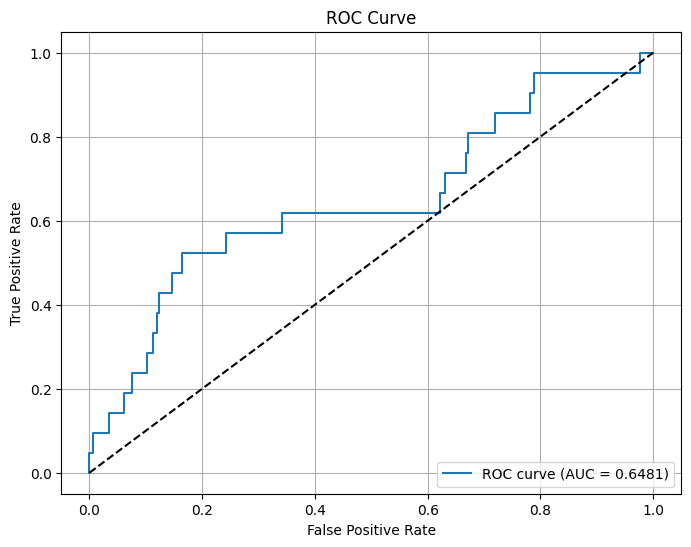

In [ ]:
# y_pred_best = best_model.predict(X_test_selected)
# cm_best, total_cost_best = DataModeler().evaluate_model(y_test, y_pred_best, return_cm_cost=True)

# # Get predicted probabilities for class 1 and AUC/ROC analysis
# y_proba = best_model.predict_proba(X_test_selected)[:, 1]
# DataModeler().auc_and_roc_curve(y_test, y_proba)